# Урок 15.19. Математическая логика: высказывания, кванторы, доказательства

**Интерактивная версия:** `lessons/lesson_15_19/web/index.html`

Каждое утверждение урока проверяем кодом: законы и рассуждения — перебором строк таблицы истинности,
свойства данных — на pandas, свойства моделей — на `gbcourse`, scikit-learn, XGBoost и LightGBM.

1. Язык высказываний и таблицы истинности: связки, импликация на данных, законы, правильные рассуждения, рыцари и лжецы.
2. Булевы функции: 16 функций двух переменных, СДНФ, минимальная ДНФ, NAND и классы Поста, сумматор.
3. Логика в данных: маски pandas, пропуски и логика Клини, импликации в метриках, правила «если — то».
4. Кванторы: all/any, порядок кванторов, пустая область, игра ε–N, проверка монотонности модели.
5. Доказательства: разбор остатков, числа Евклида, индукция и деревья, охота на контрпримеры.
6. Логика в бустинге: дерево как ДНФ, чётность и жадность, минимальные деревья, пни и XOR, мягкая логика, SAT.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math
import warnings
from functools import lru_cache
from itertools import combinations, product
from math import prod

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score
from sklearn.tree import DecisionTreeRegressor, export_text

from gbcourse.boosting import GBClassifier
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, RED
from gbcourse.tree import RegressionTree

use_course_style()
warnings.filterwarnings("ignore")
imp = lambda a, b: (not a) or b
rows = lambda n: list(product([False, True], repeat=n))

## 1. Язык высказываний и таблицы истинности

Формула от $n$ переменных — функция на $2^n$ строках. Таблица всех связок; импликация ложна только в строке 1 → 0.

In [2]:
tt = pd.DataFrame([{"A": int(a), "B": int(b), "¬A": int(not a), "A∧B": int(a and b), "A∨B": int(a or b),
                    "A⊕B": int(a != b), "A→B": int(imp(a, b)), "A↔B": int(a == b)} for a, b in rows(2)])
print(tt.to_string(index=False))

 A  B  ¬A  A∧B  A∨B  A⊕B  A→B  A↔B
 0  0   1    0    0    0    1    1
 0  1   1    0    1    1    1    0
 1  0   0    0    1    1    0    0
 1  1   0    1    1    0    1    1


Правило на данных — импликация в каждой строке. Письма из виджета шага 3: правило «спам → ссылка» и его
контрапозицию нарушает одно и то же письмо, обращение — другие.

In [3]:
mails = pd.DataFrame([
    ["Выигрыш! Заберите приз", 1, 1], ["Отчёт за квартал", 0, 0], ["Скидка 90 % только сегодня", 1, 1], ["Встреча в 15:00", 0, 0],
    ["Подтвердите пароль", 1, 1], ["Ссылка на презентацию", 0, 1], ["Вы унаследовали миллион", 1, 0], ["Обед в пятницу?", 0, 0],
    ["Кредит без проверок", 1, 1], ["Новости курса", 0, 1], ["Код-ревью: посмотрите правки", 0, 1], ["Счёт на оплату", 0, 0],
], columns=["subj", "spam", "link"], index=range(1, 13)).astype({"spam": bool, "link": bool})
claims = {"спам → ссылка": (mails.spam, mails.link), "¬ссылка → ¬спам": (~mails.link, ~mails.spam),
          "ссылка → спам": (mails.link, mails.spam), "¬спам → ¬ссылка": (~mails.spam, ~mails.link)}
for name, (P, Q) in claims.items():
    print(f"{name:18s} контрпримеры: {list(mails.index[P & ~Q])}")
assert list(mails.index[mails.spam & ~mails.link]) == [7] and list(mails.index[mails.link & ~mails.spam]) == [6, 10, 11]

спам → ссылка      контрпримеры: [7]
¬ссылка → ¬спам    контрпримеры: [7]
ссылка → спам      контрпримеры: [6, 10, 11]
¬спам → ¬ссылка    контрпримеры: [6, 10, 11]


Законы и рассуждения — перебором всех строк.

In [4]:
laws = {
    "де Морган ∧": lambda A, B, C: (not (A and B)) == ((not A) or (not B)),
    "дистрибутивность ∨ над ∧": lambda A, B, C: (A or (B and C)) == ((A or B) and (A or C)),
    "поглощение": lambda A, B, C: (A or (A and B)) == A,
    "склеивание": lambda A, B, C: ((A and B) or (A and not B)) == A,
    "экспорт": lambda A, B, C: imp(A, imp(B, C)) == imp(A and B, C),
    "закон Пирса": lambda A, B, C: imp(imp(imp(A, B), A), A),
    "контрапозиция": lambda A, B, C: imp(A, B) == imp(not B, not A),
    "обращение": lambda A, B, C: imp(A, B) == imp(B, A),
    "скобки у импликации": lambda A, B, C: imp(imp(A, B), C) == imp(A, imp(B, C)),
}
for name, law in laws.items():
    bad = [tuple(map(int, r)) for r in rows(3) if not law(*r)]
    print(f"{name:26s} {'закон' if not bad else 'НЕ закон, контрпример ' + str(bad[0])}")

entails = lambda prem, concl, n: all(concl(*r) for r in rows(n) if all(p(*r) for p in prem))
print("\n(A → B) → C ⊨ A → (B → C):", entails([lambda A, B, C: imp(imp(A, B), C)], lambda A, B, C: imp(A, imp(B, C)), 3))
print("A → (B → C) ⊨ (A → B) → C:", entails([lambda A, B, C: imp(A, imp(B, C))], lambda A, B, C: imp(imp(A, B), C), 3))
print("modus tollens:", entails([lambda A, B: imp(A, B), lambda A, B: not B], lambda A, B: not A, 2))
print("утверждение следствия:", entails([lambda A, B: imp(A, B), lambda A, B: B], lambda A, B: A, 2))

де Морган ∧                закон
дистрибутивность ∨ над ∧   закон
поглощение                 закон
склеивание                 закон
экспорт                    закон
закон Пирса                закон
контрапозиция              закон
обращение                  НЕ закон, контрпример (0, 1, 0)
скобки у импликации        НЕ закон, контрпример (0, 0, 0)

(A → B) → C ⊨ A → (B → C): True
A → (B → C) ⊨ (A → B) → C: False
modus tollens: True
утверждение следствия: False


Рыцари и лжецы: условие «X ↔ сказанное X» для каждого жителя, решения — строки, где выполнены все условия.

In [5]:
def knights(says, names):
    return [dict(zip(names, w)) for w in rows(len(names)) if all(w[names.index(p)] == f(*w) for p, f in says.items())]


print(knights({"A": lambda A, B: (not A) or (not B)}, "AB"))
print(knights({"A": lambda A, B, C: not B, "B": lambda A, B, C: not C, "C": lambda A, B, C: (not A) and (not B)}, "ABC"))
print("«Я рыцарь»:", knights({"A": lambda A: A}, "A"), " «Я лжец»:", knights({"A": lambda A: not A}, "A"))

[{'A': True, 'B': False}]
[{'A': False, 'B': True, 'C': False}]
«Я рыцарь»: [{'A': False}, {'A': True}]  «Я лжец»: []


## 2. Булевы функции

Функций от $n$ переменных $2^{2^n}$; от трёх переменных существенно зависят 218 из 256.

In [6]:
print([2 ** (2**n) for n in range(1, 7)])


def depends_on_all(tbl, n):
    R = list(product([0, 1], repeat=n))
    v = dict(zip(R, tbl))
    return all(any(v[r] != v[r[:j] + (1 - r[j],) + r[j + 1:]] for r in R) for j in range(n))


print("существенно зависят от трёх переменных:", sum(depends_on_all(t, 3) for t in product([0, 1], repeat=8)))

[4, 16, 256, 65536, 4294967296, 18446744073709551616]
существенно зависят от трёх переменных: 218


СДНФ по таблице и минимальная ДНФ (перебор импликант — кубов с «−1» на месте отсутствующей переменной).

In [7]:
def min_dnf(f, n, dont_care=()):
    R = list(product([0, 1], repeat=n))
    num = lambda r: int("".join(map(str, r)), 2)
    ones = [r for r in R if f(*r) and num(r) not in dont_care]
    ok = lambda r: f(*r) or num(r) in dont_care
    cov = lambda c, r: all(ci < 0 or ci == ri for ci, ri in zip(c, r))
    cubes = [c for c in product([-1, 0, 1], repeat=n) if all(ok(r) for r in R if cov(c, r))]
    for k in range(1, len(ones) + 1):
        good = [s for s in combinations(cubes, k) if all(any(cov(c, r) for c in s) for r in ones)]
        if good:
            return min(good, key=lambda s: sum(ci >= 0 for c in s for ci in c))
    return ()


term = lambda c: " ∧ ".join(v if b else "¬" + v for v, b in zip("ABCD", c) if b >= 0) or "1"
show = lambda s: " ∨ ".join("(" + term(c) + ")" for c in s)
print("большинство:", show(min_dnf(lambda a, b, c: a + b + c >= 2, 3)))
print("чётность:   ", show(min_dnf(lambda a, b, c: (a + b + c) % 2, 3)))
digit = lambda a, b, c, d: 5 <= 8 * a + 4 * b + 2 * c + d <= 9
print("цифры 5–9:  ", show(min_dnf(digit, 4)), "  с безразличными 10–15:", show(min_dnf(digit, 4, dont_care=range(10, 16))))
print("углы карты: ", show(min_dnf(lambda a, b, c, d: (8 * a + 4 * b + 2 * c + d) in (0, 2, 8, 10), 4)))

большинство: (B ∧ C) ∨ (A ∧ C) ∨ (A ∧ B)
чётность:    (¬A ∧ ¬B ∧ C) ∨ (¬A ∧ B ∧ ¬C) ∨ (A ∧ ¬B ∧ ¬C) ∨ (A ∧ B ∧ C)
цифры 5–9:   (¬A ∧ B ∧ D) ∨ (¬A ∧ B ∧ C) ∨ (A ∧ ¬B ∧ ¬C)   с безразличными 10–15: (B ∧ D) ∨ (B ∧ C) ∨ (A)
углы карты:  (¬B ∧ ¬D)


Полнота: всё из NAND; классы Поста (коэффициенты полинома Жегалкина — для линейности).

In [8]:
nand = lambda a, b: not (a and b)
print("¬, ∧, ∨, ⊕ из NAND:", all(nand(A, A) == (not A) and nand(nand(A, B), nand(A, B)) == (A and B)
                                   and nand(nand(A, A), nand(B, B)) == (A or B)
                                   and nand(nand(A, nand(A, B)), nand(B, nand(A, B))) == (A != B) for A, B in rows(2)))


def post(col):
    R = list(product([0, 1], repeat=2))
    v = dict(zip(R, col))
    c = list(col)
    for b in range(2):
        for i in range(4):
            if i >> b & 1:
                c[i] ^= c[i ^ (1 << b)]
    return {"T0": v[(0, 0)] == 0, "T1": v[(1, 1)] == 1, "S": all(v[r] != v[(1 - r[0], 1 - r[1])] for r in R),
            "M": all(v[a] <= v[b] for a in R for b in R if a[0] <= b[0] and a[1] <= b[1]), "L": c[3] == 0}


ops = {"¬": (1, 1, 0, 0), "∧": (0, 0, 0, 1), "∨": (0, 1, 1, 1), "→": (1, 1, 0, 1), "⊕": (0, 1, 1, 0),
       "↔": (1, 0, 0, 1), "↑": (1, 1, 1, 0), "↓": (1, 0, 0, 0), "0": (0, 0, 0, 0), "1": (1, 1, 1, 1)}
print(pd.DataFrame({k: post(v) for k, v in ops.items()}).T.replace({True: "✓", False: "·"}))
complete = lambda names: all(any(not post(ops[o])[k] for o in names) for k in ["T0", "T1", "S", "M", "L"])
print({s: complete(s.split(",")) for s in ["∧,∨", "¬,∧", "↑", "→", "→,0", "⊕,↔", "⊕,∧,1"]})

¬, ∧, ∨, ⊕ из NAND: True
  T0 T1  S  M  L
¬  ·  ·  ✓  ·  ✓
∧  ✓  ✓  ·  ✓  ·
∨  ✓  ✓  ·  ✓  ·
→  ·  ✓  ·  ·  ·
⊕  ✓  ·  ·  ·  ✓
↔  ·  ✓  ·  ·  ✓
↑  ·  ·  ·  ·  ·
↓  ·  ·  ·  ·  ·
0  ✓  ·  ·  ✓  ✓
1  ·  ✓  ·  ✓  ✓
{'∧,∨': False, '¬,∧': True, '↑': True, '→': False, '→,0': True, '⊕,↔': False, '⊕,∧,1': True}


Сумматор: $s = a \oplus b \oplus c$, перенос — большинство трёх битов.

In [9]:
def add4(x, y):
    c, out = 0, 0
    for i in range(4):
        a, b = x >> i & 1, y >> i & 1
        out |= (a ^ b ^ c) << i
        c = (a & b) | (c & (a ^ b))
    return out | c << 4


assert all(add4(x, y) == x + y for x in range(16) for y in range(16))
print("11 + 6 =", add4(11, 6), bin(add4(11, 6)))

11 + 6 = 17 0b10001


## 3. Логика в данных

Маски, законы де Моргана и ошибка приоритета.

In [10]:
rng = Mulberry32(4)
df = pd.DataFrame([{"age": 18 + rng.randint(50), "income": 20 + rng.randint(80), "churn": rng.random() < 0.3} for _ in range(12)], index=range(1, 13))
m1 = ~((df.age > 30) & (df.income < 50))
m2 = (df.age <= 30) | (df.income >= 50)
print("де Морган — те же строки:", (m1 == m2).all(), " отобрано", m1.sum(), "доля", round(m1.mean(), 3))
try:
    df[df.age > 30 & df.income < 50]
except ValueError as e:
    print("без скобок:", type(e).__name__)

де Морган — те же строки: True  отобрано 10 доля 0.833
без скобок: ValueError


Пропуски: `~(x > t)` и `x <= t` различаются, а с `pd.NA` работает логика Клини.

In [11]:
age = pd.Series([25, np.nan, 47, 33, 19, np.nan, 52, 30, 61, 28])
print(pd.DataFrame({"age": age, "age > 30": age > 30, "age <= 30": age <= 30, "~(age > 30)": ~(age > 30)}))
print("суммы масок:", (age > 30).sum(), (age <= 30).sum(), (~(age > 30)).sum())
na = pd.array([True, None, False], dtype="boolean")
print("NA | True:", (na | True)[1], " NA & False:", (na & False)[1], " NA | False:", (na | False)[1], " ~NA:", (~na)[1])
age_na = age.astype("Float64")
print("отбор с <NA> в маске:", list(age_na[age_na > 30].index), "и", list(age_na[~(age_na > 30)].index))

    age  age > 30  age <= 30  ~(age > 30)
0  25.0     False       True         True
1   NaN     False      False         True
2  47.0      True      False        False
3  33.0      True      False        False
4  19.0     False       True         True
5   NaN     False      False         True
6  52.0      True      False        False
7  30.0     False       True         True
8  61.0      True      False        False
9  28.0     False       True         True
суммы масок: 4 4 6
NA | True: True  NA & False: False  NA | False: <NA>  ~NA: <NA>
отбор с <NA> в маске: [2, 3, 6, 8] и [0, 4, 7, 9]


Метрики как доли импликаций; строгая контрапозиция и «мягкие» доли.

In [12]:
TP, FP, FN, TN = 40, 10, 30, 120
y = np.array([1] * TP + [0] * FP + [1] * FN + [0] * TN)
p = np.array([1] * TP + [1] * FP + [0] * FN + [0] * TN)
print({"точность ŷ→y": precision_score(y, p), "специфичность ¬y→¬ŷ": round(recall_score(1 - y, 1 - p), 3),
       "полнота y→ŷ": round(recall_score(y, p), 3), "NPV ¬ŷ→¬y": precision_score(1 - y, 1 - p)})
print("редкий класс (1 % спама, полнота 0.9, FP 1 %): точность", round(90 / (90 + 99), 3))

{'точность ŷ→y': 0.8, 'специфичность ¬y→¬ŷ': 0.923, 'полнота y→ŷ': 0.571, 'NPV ¬ŷ→¬y': 0.8}
редкий класс (1 % спама, полнота 0.9, FP 1 %): точность 0.476


Правила «если — то» на данных виджета шага 22: поддержка, достоверность, подъём.

In [13]:
rng = Mulberry32(19)
cl = []
for _ in range(400):
    a_ = 18 + rng.randint(53)
    tenure = rng.randint(61)
    complaint = int(rng.random() < 0.2)
    basic = int(rng.random() < 0.6)
    z = -2.2 + 1.6 * complaint + 1.0 * (tenure < 12) + 0.6 * basic + 0.4 * (a_ < 30)
    cl.append(dict(age=a_, tenure=tenure, complaint=complaint, basic=basic, churn=int(rng.random() < 1 / (1 + math.exp(-z)))))
cl = pd.DataFrame(cl)
base = cl.churn.mean()
conds = {"жалоба": cl.complaint == 1, "стаж<12": cl.tenure < 12, "базовый": cl.basic == 1, "возраст<30": cl.age < 30}
out = []
for k in (1, 2, 3):
    for c in combinations(conds, k):
        A = np.logical_and.reduce([conds[x] for x in c])
        out.append((" ∧ ".join(c), int(A.sum()), cl.churn[A].mean(), cl.churn[A].mean() / base, int((A & (cl.churn == 0)).sum())))
rules = pd.DataFrame(out, columns=["правило", "поддержка", "достоверность", "подъём", "контрпримеров"])
print(f"доля ушедших {base:.3f}")
print(rules.sort_values("подъём", ascending=False).round(3).to_string(index=False))

доля ушедших 0.195
                       правило  поддержка  достоверность  подъём  контрпримеров
    жалоба ∧ стаж<12 ∧ базовый         14          0.714   3.663              4
 жалоба ∧ базовый ∧ возраст<30          7          0.571   2.930              3
              жалоба ∧ стаж<12         24          0.542   2.778             11
 жалоба ∧ стаж<12 ∧ возраст<30          6          0.500   2.564              3
             стаж<12 ∧ базовый         52          0.481   2.465             27
              жалоба ∧ базовый         52          0.423   2.170             30
                        жалоба         86          0.395   2.027             52
           жалоба ∧ возраст<30         18          0.389   1.994             11
                       стаж<12         82          0.366   1.876             52
стаж<12 ∧ базовый ∧ возраст<30         14          0.357   1.832              9
          стаж<12 ∧ возраст<30         23          0.348   1.784             15
          базовый ∧ в

## 4. Кванторы

∀ — `all`, ∃ — `any`. Порядок кванторов, ограниченные кванторы и пустая область.

In [14]:
D = range(10)
for name, P in [("x + y = 9", lambda x, y: x + y == 9), ("y > x", lambda x, y: y > x), ("x·y = 0", lambda x, y: x * y == 0)]:
    print(f"{name:10s} ∀x∃y: {all(any(P(x, y) for y in D) for x in D)!s:5}  ∃y∀x: {any(all(P(x, y) for x in D) for y in D)}")
leaves = [(62, 0.31), (41, -0.12), (35, 0.45), (18, 0.08), (12, -0.37), (7, 0.62), (4, 0.15), (2, -0.8)]
for k in (30, 63):
    Dk = [v for n, v in leaves if n >= k]
    print(f"k = {k}: ∀x∈D v>0 = {all(v > 0 for v in Dk)}, ∃x∈D v>0.5 = {any(v > 0.5 for v in Dk)}, "
          f"ошибочно ∃x (D → v>0.5) = {any((n < k) or v > 0.5 for n, v in leaves)}")

x + y = 9  ∀x∃y: True   ∃y∀x: False
y > x      ∀x∃y: False  ∃y∀x: False
x·y = 0    ∀x∃y: True   ∃y∀x: True
k = 30: ∀x∈D v>0 = False, ∃x∈D v>0.5 = False, ошибочно ∃x (D → v>0.5) = True
k = 63: ∀x∈D v>0 = True, ∃x∈D v>0.5 = False, ошибочно ∃x (D → v>0.5) = True


Игра ε–N: наименьший подходящий номер (в пределах проверки до 5000) и проигрыш для $(-1)^n$.

In [15]:
seqs = {"1/n → 0": (lambda n: 1 / n, 0), "n/(n+1) → 1": (lambda n: n / (n + 1), 1), "(−1)^n → 0?": (lambda n: (-1) ** n, 0)}
for name, (a_n, a) in seqs.items():
    res = {}
    for eps in (0.5, 0.1, 0.01):
        bad = [n for n in range(1, 5001) if not abs(a_n(n) - a) < eps]
        res[eps] = "нет N" if bad and bad[-1] > 4990 else (bad[-1] if bad else 0)
    print(f"{name:14s}", res)

1/n → 0        {0.5: 2, 0.1: 10, 0.01: 100}
n/(n+1) → 1    {0.5: 1, 0.1: 8, 0.01: 99}
(−1)^n → 0?    {0.5: 'нет N', 0.1: 'нет N', 0.01: 'нет N'}


Монотонность модели из «ступенек»: точная проверка по интервалам и вероятность, что случайный тест найдёт провал.

In [16]:
w = 0.1
steps = [(1, 0.2), (2.5, 0.3), (4, -0.08), (4 + w, 0.08), (6, 0.25), (8, 0.2)]
f = lambda x: sum(h for t, h in steps if x > t)
edges = [0] + [t for t, _ in steps] + [10]
vals = [f((a_ + b_) / 2) for a_, b_ in zip(edges, edges[1:])]
print("значения на интервалах:", np.round(vals, 2), " монотонна:", all(a_ <= b_ for a_, b_ in zip(vals, vals[1:])))
for m in (20, 200, 1000):
    print(f"{m:5d} точек: P(найти нарушение) = {1 - (1 - w / 10) ** m - 0.85**m + (0.85 - w / 10) ** m:.3f}")

значения на интервалах: [0.   0.2  0.5  0.42 0.5  0.75 0.95]  монотонна: False
   20 точек: P(найти нарушение) = 0.174
  200 точек: P(найти нарушение) = 0.866
 1000 точек: P(найти нарушение) = 1.000


## 5. Доказательства

Разбор остатков — полное доказательство для всех целых, если ответ зависит только от остатка.

In [17]:
print("n³ − n ⋮ 6:", all((r**3 - r) % 6 == 0 for r in range(6)), "| n⁵ − n ⋮ 30:", all((r**5 - r) % 30 == 0 for r in range(30)),
      "| нечётные n: n² − 1 ⋮ 8:", all((r * r - 1) % 8 == 0 for r in range(1, 8, 2)), "| все n:", all((r * r - 1) % 8 == 0 for r in range(8)))


def factor(n):
    out, d = [], 2
    while d * d <= n:
        while n % d == 0:
            out.append(d)
            n //= d
        d += 1
    return out + ([n] if n > 1 else [])


primes = [2, 3, 5, 7, 11, 13, 17, 19, 23]
for k in range(1, 10):
    N = prod(primes[:k]) + 1
    print(k, N, factor(N))

n³ − n ⋮ 6: True | n⁵ − n ⋮ 30: True | нечётные n: n² − 1 ⋮ 8: True | все n: False
1 3 [3]
2 7 [7]
3 31 [31]
4 211 [211]
5 2311 [2311]
6 30031 [59, 509]
7 510511 [19, 97, 277]
8 9699691 [347, 27953]
9 223092871 [317, 703763]


Индукция по структуре: у деревьев sklearn любой глубины $L = I + 1$ и $L \le 2^d$.

In [18]:
r = Mulberry32(0)
X = np.array([[r.random() for _ in range(3)] for _ in range(300)])
yy = np.array([r.random() for _ in range(300)])
for d in range(1, 8):
    t = DecisionTreeRegressor(max_depth=d, random_state=0).fit(X, yy).tree_
    print(f"глубина {d}: L = {t.n_leaves:3d}, I = {t.node_count - t.n_leaves:3d}, L ≤ 2^d: {t.n_leaves <= 2**d}")

глубина 1: L =   2, I =   1, L ≤ 2^d: True
глубина 2: L =   4, I =   3, L ≤ 2^d: True
глубина 3: L =   8, I =   7, L ≤ 2^d: True
глубина 4: L =  14, I =  13, L ≤ 2^d: True
глубина 5: L =  23, I =  22, L ≤ 2^d: True
глубина 6: L =  34, I =  33, L ≤ 2^d: True
глубина 7: L =  49, I =  48, L ≤ 2^d: True


Контрпримеры к «очевидным» гипотезам.

n² + n + 41: 40 | n² − 79n + 1601: 80 | 2^(2^5) + 1 = [641, 6700417] | 2^11 − 1 = [23, 89]


нечётные составные без p + 2k²: [5777, 5993]


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


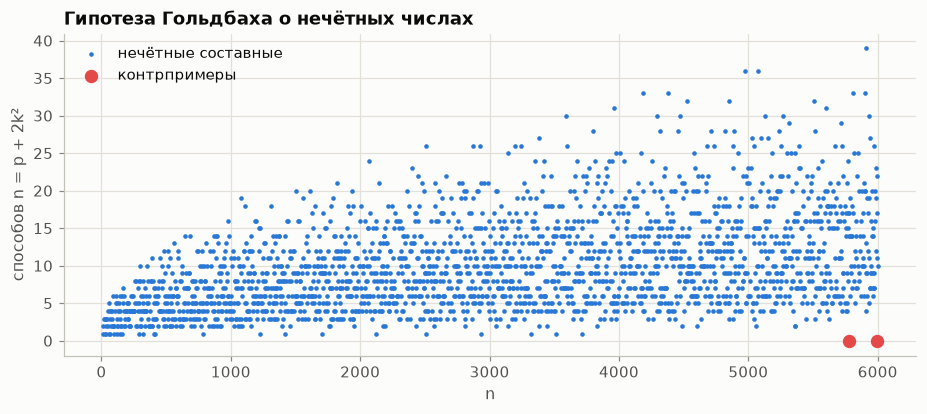

In [19]:
def is_prime(n):
    return n > 1 and all(n % d for d in range(2, int(n**0.5) + 1))


print("n² + n + 41:", next(n for n in range(100) if not is_prime(n * n + n + 41)),
      "| n² − 79n + 1601:", next(n for n in range(200) if not is_prime(n * n - 79 * n + 1601)),
      "| 2^(2^5) + 1 =", factor(2**32 + 1), "| 2^11 − 1 =", factor(2**11 - 1))
odd = np.arange(3, 6001, 2)
reps = np.array([sum(is_prime(n - 2 * k * k) for k in range(1, int((n / 2) ** 0.5) + 1)) for n in odd])
comp = np.array([not is_prime(n) for n in odd])
print("нечётные составные без p + 2k²:", odd[comp & (reps == 0)].tolist())
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.scatter(odd[comp], reps[comp], s=4, color=BLUE, label="нечётные составные")
ax.scatter(odd[comp & (reps == 0)], [0, 0], s=60, color=RED, zorder=3, label="контрпримеры")
ax.set(xlabel="n", ylabel="способов n = p + 2k²", title="Гипотеза Гольдбаха о нечётных числах")
ax.legend()
plt.show()

## 6. Логика в бустинге

### Дерево как ДНФ
Дерево `gbcourse` на данных шага 34 и то же дерево в sklearn: правила листьев совпадают.

In [20]:
rng = Mulberry32(23)
X, y = [], []
for _ in range(200):
    x1, x2 = rng.uniform(0, 10), rng.uniform(0, 10)
    c = int((x1 > 6 and x2 < 4) or (x1 < 3 and x2 > 6))
    if rng.random() < 0.05:
        c = 1 - c
    X.append([x1, x2])
    y.append(c)
X, y = np.array(X), np.array(y, float)
for d in range(1, 6):
    t = RegressionTree(max_depth=d, min_samples_leaf=5).fit(X, -y, np.ones_like(y))
    print(f"глубина {d}: листьев {t.n_leaves:2d}, точность {((t.predict(X) >= 0.5) == y).mean():.2f}")
sk = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5).fit(X, y)
print(export_text(sk, feature_names=["x1", "x2"], decimals=2))

глубина 1: листьев  2, точность 0.65
глубина 2: листьев  4, точность 0.83
глубина 3: листьев  7, точность 0.94
глубина 4: листьев 11, точность 0.94
глубина 5: листьев 13, точность 0.94
|--- x1 <= 3.01
|   |--- x2 <= 5.92
|   |   |--- x1 <= 1.70
|   |   |   |--- value: [0.04]
|   |   |--- x1 >  1.70
|   |   |   |--- value: [0.17]
|   |--- x2 >  5.92
|   |   |--- value: [1.00]
|--- x1 >  3.01
|   |--- x2 <= 3.80
|   |   |--- x1 <= 5.69
|   |   |   |--- value: [0.00]
|   |   |--- x1 >  5.69
|   |   |   |--- value: [0.89]
|   |--- x2 >  3.80
|   |   |--- x1 <= 8.93
|   |   |   |--- value: [0.03]
|   |   |--- x1 >  8.93
|   |   |   |--- value: [0.33]



### Чётность и жадность
Чётность $k$ из 6 двоичных признаков: корень дерева выбирается по шуму, точность на тесте растёт только с глубиной.

k = 1: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
k = 2: [0.501, 0.541, 0.53, 0.766, 0.883, 1.0, 1.0, 1.0]
k = 3: [0.53, 0.515, 0.505, 0.536, 0.668, 0.964, 0.964, 0.964]


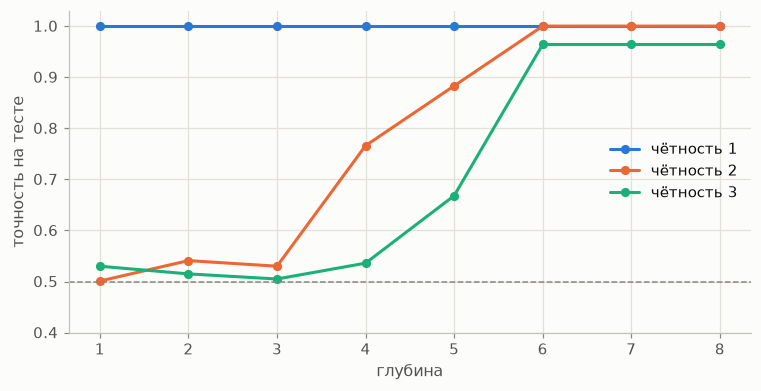

In [21]:
curves = {}
for k in (1, 2, 3):
    rng = Mulberry32(5)
    mk = lambda m, rng=rng: np.array([[int(rng.random() < 0.5) for _ in range(6)] for _ in range(m)], float)
    Xtr, Xte = mk(400), mk(1000)
    lab = lambda Z, k=k: (Z[:, :k].sum(axis=1) % 2).astype(float)
    ytr, yte = lab(Xtr), lab(Xte)
    curves[k] = [((RegressionTree(max_depth=d).fit(Xtr, -ytr, np.ones(400)).predict(Xte) >= 0.5) == yte).mean() for d in range(1, 9)]
    print(f"k = {k}:", np.round(curves[k], 3).tolist())
fig, ax = plt.subplots(figsize=(8, 3.8))
for k, col in zip((1, 2, 3), (BLUE, ORANGE, AQUA)):
    ax.plot(range(1, 9), curves[k], marker="o", color=col, lw=2, label=f"чётность {k}")
ax.axhline(0.5, color=MUTED, ls="--", lw=1)
ax.set(xlabel="глубина", ylabel="точность на тесте", ylim=(0.4, 1.03))
ax.legend()
plt.show()

### Минимальное и жадное дерево
Перебор подкубов даёт минимальное число листьев; жадное дерево (Джини) больше у 16 % функций трёх переменных.

In [22]:
def tree_sizes(tbl, n):
    R = list(product([0, 1], repeat=n))
    vals = lambda cube: [v for r, v in zip(R, tbl) if all(c < 0 or c == x for c, x in zip(cube, r))]
    gini = lambda v: 2 * np.mean(v) * (1 - np.mean(v))

    @lru_cache(None)
    def best(cube):
        if len(set(vals(cube))) == 1:
            return 1
        return min(best(cube[:j] + (0,) + cube[j + 1:]) + best(cube[:j] + (1,) + cube[j + 1:]) for j in range(n) if cube[j] < 0)

    def greedy(cube):
        v = vals(cube)
        if len(set(v)) == 1:
            return 1
        g = {j: gini(v) - 0.5 * gini(vals(cube[:j] + (0,) + cube[j + 1:])) - 0.5 * gini(vals(cube[:j] + (1,) + cube[j + 1:]))
             for j in range(n) if cube[j] < 0}
        j = next(j for j in g if g[j] > max(g.values()) - 1e-12)
        return greedy(cube[:j] + (0,) + cube[j + 1:]) + greedy(cube[:j] + (1,) + cube[j + 1:])

    return best((-1,) * n), greedy((-1,) * n)


tab = lambda f, n: tuple(int(f(*r)) for r in product([0, 1], repeat=n))
print("селектор A ? B : C:", tree_sizes(tab(lambda a, b, c: b if a else c, 3), 3), " чётность 3:", tree_sizes(tab(lambda a, b, c: a ^ b ^ c, 3), 3))
all3 = [tree_sizes(t, 3) for t in product([0, 1], repeat=8)]
print("жадное больше минимального:", sum(g > m for m, g in all3), "из 256")

селектор A ? B : C: (4, 6)  чётность 3: (8, 8)


жадное больше минимального: 42 из 256


### Пни, XOR и симметрия
Сумма пней аддитивна: $F_{00} + F_{11} - F_{01} - F_{10} = 0$. На идеально сбалансированном XOR деревья глубины 2
не делают ни одного разбиения в gbcourse, XGBoost и LightGBM; sklearn делит и при нулевом выигрыше.

In [23]:
cells = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], float)


def cells_data(f, extra=0):
    Xc = np.array([[a, b] for a in (0, 1) for b in (0, 1) for _ in range(25 + (extra if a and b else 0))], float)
    return Xc, np.array([f(int(a), int(b)) for a, b in Xc])


for name, fn in [("AND", lambda a, b: a & b), ("XOR", lambda a, b: a ^ b)]:
    Xc, yc = cells_data(fn)
    F = GBClassifier(n_estimators=100, learning_rate=0.3, max_depth=1).fit(Xc, yc).predict_raw(cells)
    print(f"{name}, пни: F = {np.round(F, 2)}, взаимодействие {F[0] + F[3] - F[1] - F[2]:+.1e}")
for extra in (0, 1):
    Xc, yc = cells_data(lambda a, b: a ^ b, extra)
    acc = {
        "gbcourse": (GBClassifier(n_estimators=100, learning_rate=0.3, max_depth=2).fit(Xc, yc).predict(Xc) == yc).mean(),
        "XGBoost": (xgb.XGBClassifier(n_estimators=100, learning_rate=0.3, max_depth=2).fit(Xc, yc).predict(Xc) == yc).mean(),
        "LightGBM": (lgb.LGBMClassifier(n_estimators=100, learning_rate=0.3, max_depth=2, num_leaves=4, min_child_samples=1, verbose=-1).fit(Xc, yc).predict(Xc) == yc).mean(),
        "sklearn": GradientBoostingClassifier(n_estimators=100, learning_rate=0.3, max_depth=2).fit(Xc, yc).score(Xc, yc)}
    print(f"XOR, глубина 2, лишних объектов {extra}:", {k: round(float(v), 3) for k, v in acc.items()})

AND, пни: F = [-32.39 -10.89 -11.09  10.4 ], взаимодействие -1.8e-15
XOR, пни: F = [0. 0. 0. 0.], взаимодействие +0.0e+00


XOR, глубина 2, лишних объектов 0: {'gbcourse': 0.5, 'XGBoost': 0.5, 'LightGBM': 0.5, 'sklearn': 1.0}


XOR, глубина 2, лишних объектов 1: {'gbcourse': 1.0, 'XGBoost': 1.0, 'LightGBM': 1.0, 'sklearn': 1.0}


### Мягкая логика
Границы Фреше и разница между вероятностью импликации и условной вероятностью.

In [24]:
pa, pb = 0.7, 0.6
print("P(A ∧ B) ∈", [round(max(0, pa + pb - 1), 3), min(pa, pb)], " при независимости", pa * pb)
print("P(A → B) =", round(1 - pa + pa * pb, 3), " P(B | A) =", pb)
for nm, T in {"min": min, "произведение": lambda a, b: a * b, "Лукасевич": lambda a, b: max(0, a + b - 1)}.items():
    print(f"{nm:13s} T(0.5, 0.5) = {T(0.5, 0.5):.2f}, углы: {[T(a, b) for a in (0, 1) for b in (0, 1)]}")

P(A ∧ B) ∈ [0.3, 0.6]  при независимости 0.42
P(A → B) = 0.72  P(B | A) = 0.6
min           T(0.5, 0.5) = 0.50, углы: [0, 0, 0, 1]
произведение  T(0.5, 0.5) = 0.25, углы: [0, 0, 0, 1]
Лукасевич     T(0.5, 0.5) = 0.00, углы: [0, 0, 0, 1]


### SAT: DPLL
Распространение единичных дизъюнктов и откат; раскраски графов и судоку 4 × 4.

In [25]:
def dpll(clauses, n):
    val = [0] * (n + 1)
    trail, st = [], {"decide": 0, "unit": 0, "conflict": 0}
    lit = lambda q: 0 if val[abs(q)] == 0 else (1 if (q > 0) == (val[abs(q)] > 0) else -1)

    def assign(q, why, flipped=False):
        val[abs(q)] = 1 if q > 0 else -1
        trail.append((q, why, flipped))

    def propagate():
        while True:
            changed = False
            for c in clauses:
                vs = [lit(q) for q in c]
                if 1 in vs:
                    continue
                free = [q for q, v in zip(c, vs) if v == 0]
                if not free:
                    return c
                if len(free) == 1:
                    assign(free[0], "unit")
                    st["unit"] += 1
                    changed = True
            if not changed:
                return None

    conflict = propagate()
    while True:
        if conflict:
            st["conflict"] += 1
            while trail:
                q, why, flipped = trail.pop()
                val[abs(q)] = 0
                if why == "decide" and not flipped:
                    break
            else:
                return None, st
            assign(-q, "decide", True)
            st["decide"] += 1
            conflict = propagate()
            continue
        free = [v for v in range(1, n + 1) if val[v] == 0]
        if not free:
            return val, st
        assign(free[0], "decide")
        st["decide"] += 1
        conflict = propagate()


def coloring(V, E, k=3):
    x = lambda v, c: v * k + c + 1
    cl = [[x(v, c) for c in range(k)] for v in range(V)]
    cl += [[-x(v, a), -x(v, b)] for v in range(V) for a in range(k) for b in range(a + 1, k)]
    cl += [[-x(u, c), -x(v, c)] for u, v in E for c in range(k)]
    return cl, V * k


sv = lambda r_, c_, d_: r_ * 16 + c_ * 4 + d_ + 1
groups = [[(r_, c_) for c_ in range(4)] for r_ in range(4)] + [[(r_, c_) for r_ in range(4)] for c_ in range(4)]
groups += [[(2 * i + a, 2 * j + b) for a in (0, 1) for b in (0, 1)] for i in (0, 1) for j in (0, 1)]
sud = [[sv(r_, c_, d_) for d_ in range(4)] for r_ in range(4) for c_ in range(4)]
sud += [[-sv(r_, c_, a), -sv(r_, c_, b)] for r_ in range(4) for c_ in range(4) for a in range(4) for b in range(a + 1, 4)]
for g in groups:
    for d_ in range(4):
        sud.append([sv(r_, c_, d_) for r_, c_ in g])
        sud += [[-sv(*g[a], d_), -sv(*g[b], d_)] for a in range(4) for b in range(a + 1, 4)]
given = [[1, 0, 0, 4], [0, 4, 1, 0], [2, 0, 0, 3], [0, 3, 2, 0]]
sud += [[sv(r_, c_, d_ - 1)] for r_, row in enumerate(given) for c_, d_ in enumerate(row) if d_]
tasks = {"цикл C5, 3 цвета": coloring(5, [(i, (i + 1) % 5) for i in range(5)]),
         "K4, 3 цвета": coloring(4, list(combinations(range(4), 2))), "судоку 4 × 4": (sud, 64)}
for name, (cl_, n) in tasks.items():
    model, st = dpll(cl_, n)
    print(f"{name:18s} {'выполнима' if model else 'невыполнима':12s} {st}  (перебор: 2^{n} наборов)")

цикл C5, 3 цвета   выполнима    {'decide': 4, 'unit': 11, 'conflict': 0}  (перебор: 2^15 наборов)
K4, 3 цвета        невыполнима  {'decide': 10, 'unit': 43, 'conflict': 6}  (перебор: 2^12 наборов)
судоку 4 × 4       выполнима    {'decide': 0, 'unit': 64, 'conflict': 0}  (перебор: 2^64 наборов)


## Упражнения

12 задач — в `exercises/tasks.md`, решения — в `exercises/solutions.py`: тавтологии, перевод, отрицания с
кванторами, рыцари и лжецы, всё через NOR, карта Карно, маски с пропусками, метрики, индукция, разбор остатков,
аддитивность пней на данных Фридмана и SAT для раскраски циклов.